In [54]:
import numpy as np
import scipy.constants as sc
import matplotlib.pyplot as plt
from pygmid import Lookup as lk
from scipy.interpolate import interp1d
from scipy.interpolate import CubicSpline
pmos4 = lk('lookup_table/035/pmos4.mat')
nmos4 = lk('lookup_table/035/nmos4.mat')
# Interpolation function
def interp1(x, y, value):
    # Perform cubic interpolation using interp1d
    f = interp1d(x, y, kind='cubic')
    return f(value)

Constant gm Bias current gen  
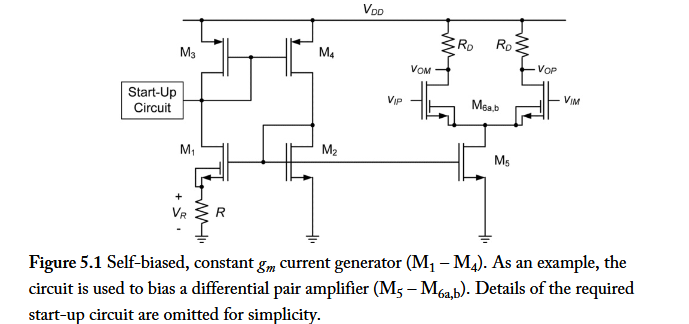 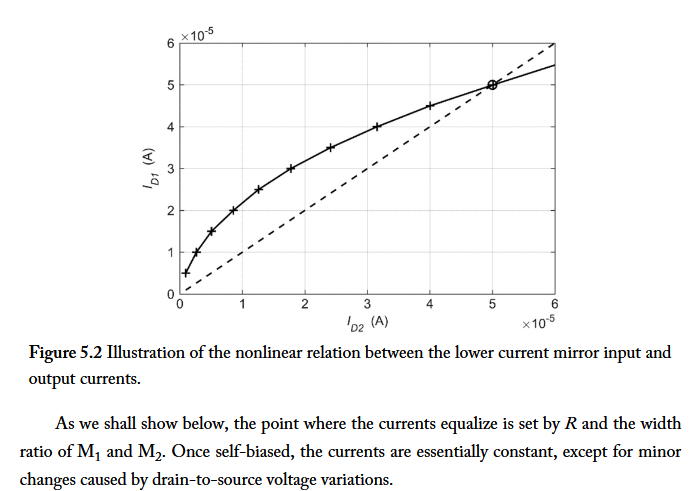

In [55]:
#Specification
VDD = 1.2
ID = 5e-6
VR = 0.1


In [56]:
#Hypothèse : L for low speed, same L for P/NMOS
L12 = 0.35

In [57]:
#Plot of AV0 and FT versus gm/id
VGS2 = np.linspace(0.4, 0.8, 50)

JD2 = np.diag(nmos4.look_up('ID_W', VGS = VGS2, VDS=VGS2, L=L12))
JD1 = np.diag(nmos4.look_up('ID_W', VGS = VGS2-VR, VDS=VGS2-VR, L=L12))
JD3 = np.diag(pmos4.look_up('ID_W', VGS = VDD-VGS2, VDS=VDD-VGS2, L=L12))

gm_ID2 = np.diag(nmos4.look_up('GM_ID',VGS = VGS2, VDS=VGS2, L=L12))
gm_ID1 = np.diag(nmos4.look_up('GM_ID', VGS = VGS2-VR, VDS=VGS2-VR, L=L12))
gm_ID3 = np.diag(pmos4.look_up('GM_ID', VGS = VDD-VGS2, VDS=VDD-VGS2, L=L12))



W2 = ID / JD2
W1 = ID / JD1
W3 = ID / JD3


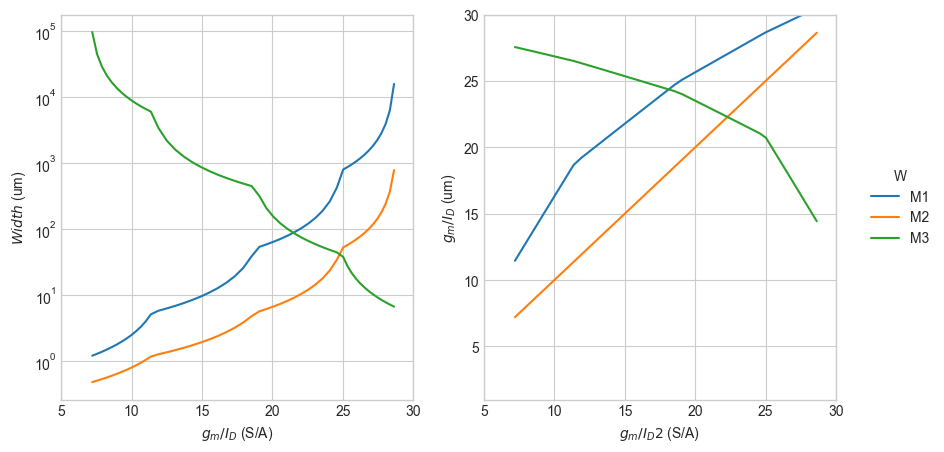

In [58]:
#Plot of AV0 and FT versus gm/id
plt.style.use("seaborn-v0_8-whitegrid")

fig, (ax1,ax2) = plt.subplots(1,2, figsize=(10, 5))
ax1.semilogy(gm_ID2, W1)
ax1.semilogy(gm_ID2, W2)
ax1.semilogy(gm_ID2, W3)
ax1.set_xlim(5, 30)
ax1.set_xlabel('$g_m/I_D$ (S/A)')
ax1.set_ylabel(r'$Width$ (um)')

#ax2 = ax1.twinx()
#ax2.semilogy(gmid_test, AV0.transpose(),linestyle='--')
#plt.ylabel(r'$AV_0/$ (V/V)')
#ax1.legend(loc='center right', bbox_to_anchor=(1.3, 0.5), title='W', labels=['W2', 'W1', 'W3'])

#Plot of AV0 and FT versus gm/id
ax2.plot(gm_ID2, gm_ID1)
ax2.plot(gm_ID2, gm_ID2)
ax2.plot(gm_ID2, gm_ID3)
ax2.set_ylim(1, 30)
ax2.set_xlim(5, 30)
ax2.set_xlabel('$g_m/I_D2$ (S/A)')
ax2.set_ylabel(r'$g_m/I_D$ (um)')
plt.style.use("seaborn-v0_8-whitegrid")

#ax2 = ax1.twinx()
#ax2.semilogy(gmid_test, AV0.transpose(),linestyle='--')
#plt.ylabel(r'$AV_0/$ (V/V)')
ax2.legend(loc='center right', bbox_to_anchor=(1.3, 0.5), title='W', labels=['M1', 'M2', 'M3'])

plt.show()


In [59]:
#Choose W2 with plot above 

w2 = 10
w1 = interp1(W2,W1,w2)
w3 = interp1(W2,W3,w2)

widths = [w1, w2, w3]

gm_Id1 = interp1(W2,gm_ID1,w2)
gm_Id2 = interp1(W2,gm_ID2,w2)
gm_Id3 = interp1(W2,gm_ID3,w2)

gms = [gm_Id1, gm_Id2, gm_Id3]

print(widths)
print(gms)

[array(98.68300127), 10, array(76.0726278)]
[array(26.82105742), array(21.94015828), array(22.47638447)]
